# Assignment-15 : Core Algorithms, Metrics & Model Behavior

## Name - Suryansh Tiwari

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")

df.columns = df.columns.str.strip()

print(df.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [3]:
print(df.info())

print("\nShape:", df.shape)

print("\nMissing Values")

print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB
None

Shape: (1000, 9)

Missing Values
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


## Part-1 : regression

In [6]:
X = df[["Age", "Quantity", "Price per Unit"]]
y = df["Total Amount"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ -0.9 ,179.56, 2.49]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Age','Quantity','Price per Unit']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-400.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [10]:
y_pred=linear_model.predict(X_test)

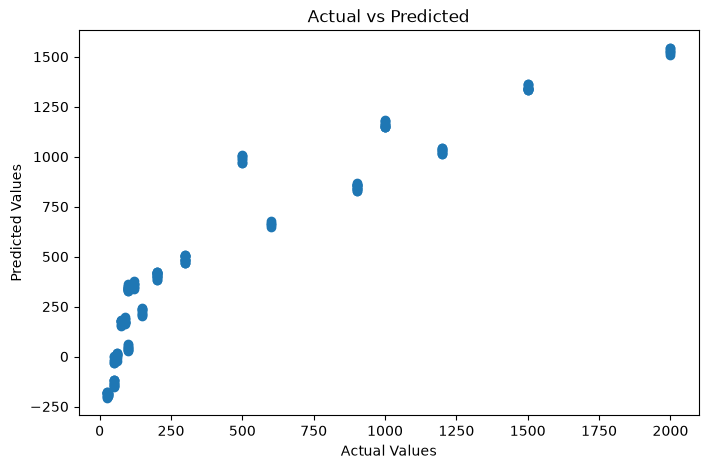

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

## Part-2 : Regression Metrics

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)

MAE : 173.11610215441945
MSE : 41896.213221343605
RMSE : 204.68564488342508


### Interpretation

- MAE represents the average prediction error.
- MSE gives more weight to larger errors.
- RMSE is the square root of MSE and is expressed in the same units as the target variable.

## Part-3 : Classification

In [13]:
median_value = df["Total Amount"].median()
df["Revenue Category"] = np.where(
    df["Total Amount"] >= median_value,
    1,0
)
print(df["Revenue Category"].value_counts())

Revenue Category
1    500
0    500
Name: count, dtype: int64


In [14]:
X = df[["Age", "Quantity", "Price per Unit"]]
y=df["Revenue Category"]

In [15]:
X_train,X_test,y_train,y_test=train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

## Task-3 : Logistic Regression

In [16]:
log_model = LogisticRegression()
log_model.fit(X_train,y_train)
log_pred = log_model.predict(X_test)
print(log_pred[:10])

[1 0 1 0 1 0 0 1 1 1]


## Task-4 : Naive Bayes

In [17]:
nb_model = GaussianNB()
nb_model.fit(X_train,y_train)
nb_pred = nb_model.predict(X_test)

## Task-5 : KNN

In [18]:
k_values = [3,5,7]
knn_results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    pred = knn.predict(X_test)
    acc = accuracy_score(y_test,pred)
    knn_results[k]=acc
    print("k =",k,"Accuracy =",acc)

k = 3 Accuracy = 0.99
k = 5 Accuracy = 0.985
k = 7 Accuracy = 0.99


In [19]:
best_k=max(knn_results,key=knn_results.get)
print("Best k:",best_k)

Best k: 3


## Part-4 : Classification Metrics

In [20]:
print("Accuracy :",accuracy_score(y_test,log_pred))
print("Precision :",precision_score(y_test,log_pred))
print("Recall :",recall_score(y_test,log_pred))
print("F1 Score :",f1_score(y_test,log_pred))
print(classification_report(y_test,log_pred))
print(confusion_matrix(y_test,log_pred))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        90
           1       1.00      1.00      1.00       110

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

[[ 90   0]
 [  0 110]]


In [21]:
print("Accuracy :",accuracy_score(y_test,nb_pred))
print("Precision :",precision_score(y_test,nb_pred))
print("Recall :",recall_score(y_test,nb_pred))
print("F1 Score :",f1_score(y_test,nb_pred))
print(classification_report(y_test,nb_pred))
print(confusion_matrix(y_test,nb_pred))

Accuracy : 0.87
Precision : 1.0
Recall : 0.7636363636363637
F1 Score : 0.865979381443299
              precision    recall  f1-score   support

           0       0.78      1.00      0.87        90
           1       1.00      0.76      0.87       110

    accuracy                           0.87       200
   macro avg       0.89      0.88      0.87       200
weighted avg       0.90      0.87      0.87       200

[[90  0]
 [26 84]]


In [22]:
best_knn = KNeighborsClassifier(
    n_neighbors=best_k
)

best_knn.fit(X_train,y_train)
knn_pred=best_knn.predict(X_test)
print("Accuracy :",accuracy_score(y_test,knn_pred))
print("Precision :",precision_score(y_test,knn_pred))
print("Recall :",recall_score(y_test,knn_pred))
print("F1 Score :",f1_score(y_test,knn_pred))
print(classification_report(y_test,knn_pred))
print(confusion_matrix(y_test,knn_pred))

Accuracy : 0.99
Precision : 1.0
Recall : 0.9818181818181818
F1 Score : 0.9908256880733946
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        90
           1       1.00      0.98      0.99       110

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200

[[ 90   0]
 [  2 108]]


## Part-5 : Overfitting & Underfitting

In [23]:
simple_model = KNeighborsClassifier(
    n_neighbors=25
)
simple_model.fit(X_train,y_train)
print(
    "Training Accuracy:",
    simple_model.score(X_train,y_train)
)
print(
    "Testing Accuracy:",
    simple_model.score(X_test,y_test)
)

Training Accuracy: 0.9375
Testing Accuracy: 0.9


In [24]:
complex_model = KNeighborsClassifier(
    n_neighbors=1
)
complex_model.fit(X_train,y_train)
print(
    "Training Accuracy:",
    complex_model.score(X_train,y_train)
)
print(
    "Testing Accuracy:",
    complex_model.score(X_test,y_test)
)

Training Accuracy: 1.0
Testing Accuracy: 1.0


### Observation

- A very large value of k may underfit because it oversimplifies the decision boundary.
- A very small value of k (such as 1) may overfit because it memorizes the training data.
- Comparing training and testing accuracy helps identify whether a model is underfitting or overfitting.

## Bias & Variance

### 1. What is Bias?

Bias is the error caused by making overly simple assumptions in the learning algorithm. High bias can lead to underfitting.

### 2. What is Variance?

Variance is the model's sensitivity to changes in the training data. High variance can lead to overfitting.

### 3. How are bias and variance related to underfitting and overfitting?

Underfitting usually occurs when bias is high and variance is low. Overfitting usually occurs when bias is low and variance is high.

### 4. How can we reduce overfitting?

- Collect more training data.
- Use simpler models.
- Apply regularization techniques.
- Perform cross-validation.
- Reduce unnecessary features.